In [1]:
from pathlib import Path
import pandas as pd

DATA_PATH = Path(
    "data/processed/daphnet_integrated.parquet"
)

print("Dataset path:", DATA_PATH)
print("Checking file existence", DATA_PATH.exists())

Dataset path: data\processed\daphnet_integrated.parquet
Checking file existence False


In [14]:
DATA_PATH = (
    Path("..")
    / "data"
    / "processed"
    / "daphnet_integrated.parquet"
)

print("Dataset path:", DATA_PATH)
print("Does the file exist?", DATA_PATH.exists())

Dataset path: ..\data\processed\daphnet_integrated.parquet
Does the file exist? True


In [6]:
import pandas as pd

df = pd.read_parquet(DATA_PATH)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

Dataset loaded successfully.
Dataset shape: (1917887, 14)


In [8]:
print(df.columns.tolist())

['time_ms', 'ankle_forward_mg', 'ankle_vertical_mg', 'ankle_lateral_mg', 'thigh_forward_mg', 'thigh_vertical_mg', 'thigh_lateral_mg', 'trunk_forward_mg', 'trunk_vertical_mg', 'trunk_lateral_mg', 'annotation', 'participant_id', 'recording_id', 'source_file']


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1917887 entries, 0 to 1917886
Data columns (total 14 columns):
 #   Column             Dtype
---  ------             -----
 0   time_ms            int64
 1   ankle_forward_mg   int64
 2   ankle_vertical_mg  int64
 3   ankle_lateral_mg   int64
 4   thigh_forward_mg   int64
 5   thigh_vertical_mg  int64
 6   thigh_lateral_mg   int64
 7   trunk_forward_mg   int64
 8   trunk_vertical_mg  int64
 9   trunk_lateral_mg   int64
 10  annotation         int64
 11  participant_id     str  
 12  recording_id       str  
 13  source_file        str  
dtypes: int64(11), str(3)
memory usage: 375.0 MB


In [10]:
first_row = df.iloc[0]

print(first_row)

time_ms                                                             15
ankle_forward_mg                                                    70
ankle_vertical_mg                                                   39
ankle_lateral_mg                                                  -970
thigh_forward_mg                                                     0
thigh_vertical_mg                                                    0
thigh_lateral_mg                                                     0
trunk_forward_mg                                                     0
trunk_vertical_mg                                                    0
trunk_lateral_mg                                                     0
annotation                                                           0
participant_id                                                     S01
recording_id                                                       R01
source_file          C:\Users\chira\Parkinsons_Fog_Detection\data\r...
Name: 

In [12]:
df = pd.read_parquet(DATA_PATH)

In [ ]:
df.head()

,time_ms,ankle_forward_mg,ankle_vertical_mg,ankle_lateral_mg,thigh_forward_mg,thigh_vertical_mg,thigh_lateral_mg,trunk_forward_mg,trunk_vertical_mg,trunk_lateral_mg,annotation,participant_id,recording_id,source_file
0,15,70,39,-970,0,0,0,0,0,0,0,S01,R01,S01R01.txt
1,31,70,39,-970,0,0,0,0,0,0,0,S01,R01,S01R01.txt
2,46,60,49,-960,0,0,0,0,0,0,0,S01,R01,S01R01.txt
3,62,60,49,-960,0,0,0,0,0,0,0,S01,R01,S01R01.txt
4,78,50,39,-960,0,0,0,0,0,0,0,S01,R01,S01R01.txt


In [16]:
participant_count = df["participant_id"].nunique()

print("Number of participants:", participant_count)

Number of participants: 10


In [17]:
recording_count = (
    df[["participant_id", "recording_id"]]
    .drop_duplicates()
    .shape[0]
)

print("Number of recordings:", recording_count)

Number of recordings: 17


In [ ]:
first_row = df.drop(columns="source_file").iloc[0]

print(first_row)
# This is like what one snapshot would look like.

time_ms                15
ankle_forward_mg       70
ankle_vertical_mg      39
ankle_lateral_mg     -970
thigh_forward_mg        0
thigh_vertical_mg       0
thigh_lateral_mg        0
trunk_forward_mg        0
trunk_vertical_mg       0
trunk_lateral_mg        0
annotation              0
participant_id        S01
recording_id          R01
Name: 0, dtype: object


In [19]:
analysis_df = df.drop(
    columns="source_file"
).copy()

print("Analysis copy created.")
print("Rows:", analysis_df.shape[0])
print("Columns:", analysis_df.shape[1])

Analysis copy created.
Rows: 1917887
Columns: 13


In [20]:
print(
    "Missing values:",
    analysis_df.isna().sum().sum()
)

print(
    "Duplicate rows:",
    analysis_df.duplicated().sum()
)

Missing values: 0
Duplicate rows: 0


In [21]:
label_counts = (
    analysis_df["annotation"]
    .value_counts()
    .sort_index()
)

label_counts

annotation
0     777052
1    1030050
2     110785
Name: count, dtype: int64

In [22]:
experimental_df = analysis_df[
    analysis_df["annotation"].isin([1, 2])
].copy()

freezing_percentage = (
    experimental_df["annotation"].eq(2).mean()
    * 100
)

print(
    "Experimental samples:",
    len(experimental_df)
)

print(
    "Freezing percentage:",
    round(freezing_percentage, 2),
    "%"
)

Experimental samples: 1140835
Freezing percentage: 9.71 %


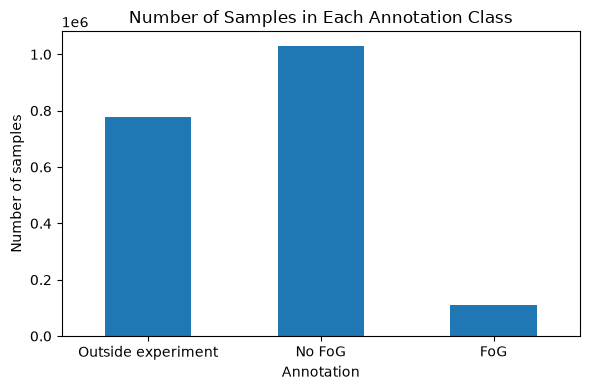

In [23]:
import matplotlib.pyplot as plt

label_counts.plot(
    kind="bar",
    figsize=(6, 4)
)

plt.title("Number of Samples in Each Annotation Class")
plt.xlabel("Annotation")
plt.ylabel("Number of samples")
plt.xticks(
    [0, 1, 2],
    ["Outside experiment", "No FoG", "FoG"],
    rotation=0
)

plt.tight_layout()
plt.show()

Sorting and calculating the time gaps

In [24]:
ordered_df = analysis_df.sort_values(
    [
        "participant_id",
        "recording_id",
        "time_ms"
    ]
).copy()

ordered_df["time_gap_ms"] = (
    ordered_df
    .groupby(
        ["participant_id", "recording_id"]
    )["time_ms"]
    .diff()
)

print("Time-gap calculation completed.")

Time-gap calculation completed.


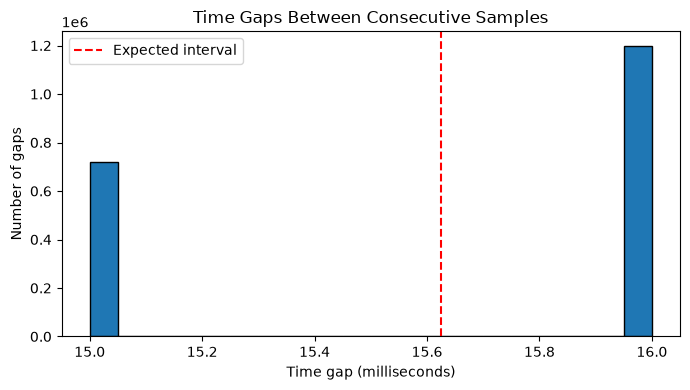

In [25]:
sampling_frequency_hz = 64
expected_interval_ms = 1000 / sampling_frequency_hz

time_gaps = (
    ordered_df["time_gap_ms"]
    .dropna()
)

plt.figure(figsize=(7, 4))

plt.hist(
    time_gaps,
    bins=20,
    edgecolor="black"
)

plt.axvline(
    expected_interval_ms,
    color="red",
    linestyle="--",
    label="Expected interval"
)

plt.title("Time Gaps Between Consecutive Samples")
plt.xlabel("Time gap (milliseconds)")
plt.ylabel("Number of gaps")
plt.legend()
plt.tight_layout()
plt.show()

### Interpretation: Time gaps between samples

Each row is one sensor reading. The time gap is the difference between the current timestamp and the previous timestamp within the same recording.

The sensors were sampled at approximately 64 Hz, so the expected gap is:
15.625 ms
Because timestamps are stored as whole milliseconds, values around 15 or 16 milliseconds are expected.

If most values are concentrated around 15–16 milliseconds, the recordings were sampled regularly. Very large gaps would indicate a possible interruption or missing period in the recording. We will investigate such gaps later instead of removing them automatically.

In [26]:
recording_df = analysis_df[
    (analysis_df["participant_id"] == "S01")
    & (analysis_df["recording_id"] == "R01")
].sort_values("time_ms").copy()

print("Rows in selected recording:", len(recording_df))

Rows in selected recording: 151987


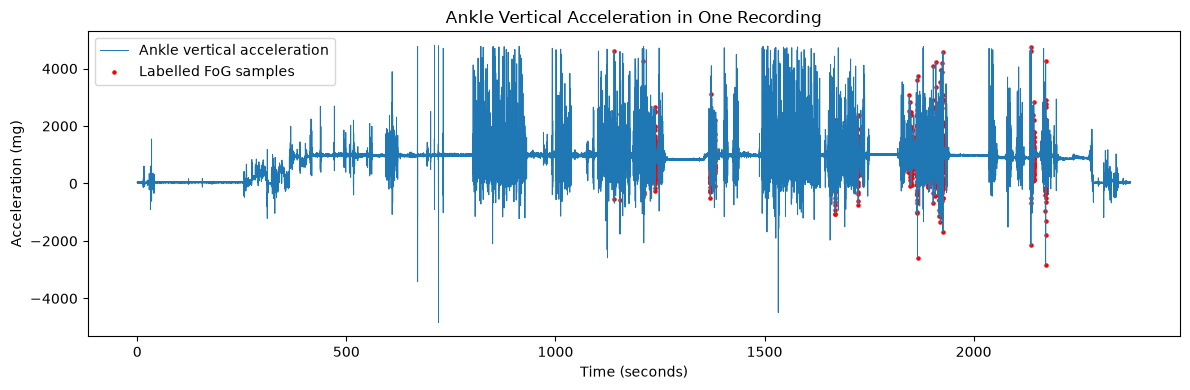

In [27]:
time_seconds = recording_df["time_ms"] / 1000

fog_rows = (
    recording_df["annotation"] == 2
)

plt.figure(figsize=(12, 4))

plt.plot(
    time_seconds,
    recording_df["ankle_vertical_mg"],
    linewidth=0.7,
    label="Ankle vertical acceleration"
)

plt.scatter(
    time_seconds[fog_rows],
    recording_df.loc[fog_rows, "ankle_vertical_mg"],
    color="red",
    s=5,
    label="Labelled FoG samples"
)

plt.title("Ankle Vertical Acceleration in One Recording")
plt.xlabel("Time (seconds)")
plt.ylabel("Acceleration (mg)")
plt.legend()
plt.tight_layout()
plt.show()

### Interpretation: Consecutive accelerometer readings

The line shows how the ankle's vertical acceleration changes over time. Each point represents one movement snapshot, and connecting consecutive points shows the movement sequence.

Smooth repeated patterns may represent regular movement, while sudden changes or spikes may represent rapid movement, noise or a transition in activity.

The red points indicate samples that the dataset has labelled as FoG. These are ground-truth labels, not predictions from our model. This graph helps us inspect whether the sensor signal appears to change around labelled FoG samples, but one sensor axis in one recording is not enough to establish a general FoG pattern.

In [28]:
participant_counts = pd.crosstab(
    analysis_df["participant_id"],
    analysis_df["annotation"]
)

participant_counts = participant_counts.reindex(
    columns=[0, 1, 2],
    fill_value=0
)

participant_counts.columns = [
    "Outside experiment",
    "No FoG",
    "FoG"
]

participant_counts

,Outside experiment,No FoG,FoG
participant_id,,,
S01,82479,114909,6694
S02,71644,78953,11609
S03,124589,110304,18340
S04,63255,132482,0
S05,76866,103396,30370
S06,92569,118952,8413
S07,66818,97829,5213
S08,87305,36425,12859
S09,60946,94078,17287


In [29]:
participant_experimental = participant_counts[
    ["No FoG", "FoG"]
]

participant_percentages = (
    participant_experimental
    .div(
        participant_experimental.sum(axis=1),
        axis=0
    )
    * 100
)

participant_percentages.round(2)

,No FoG,FoG
participant_id,,
S01,94.50,5.50
S02,87.18,12.82
S03,85.74,14.26
S04,100.00,0.00
S05,77.30,22.70
S06,93.39,6.61
S07,94.94,5.06
S08,73.91,26.09
S09,84.48,15.52


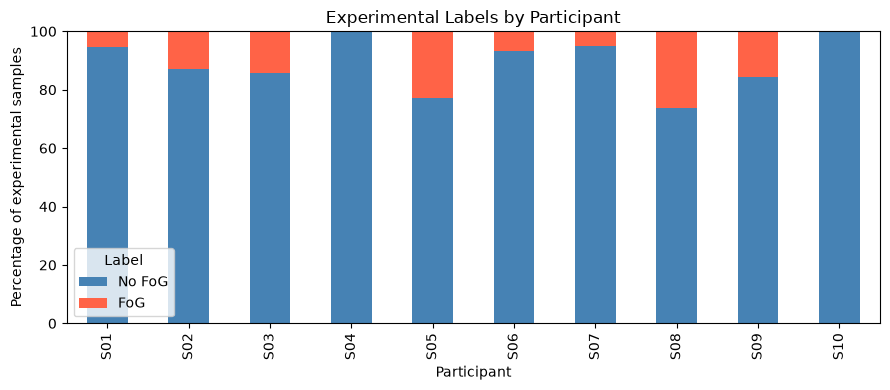

In [30]:
participant_percentages.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 4),
    color=["steelblue", "tomato"]
)

plt.title("Experimental Labels by Participant")
plt.xlabel("Participant")
plt.ylabel("Percentage of experimental samples")
plt.legend(
    title="Label",
    labels=["No FoG", "FoG"]
)

plt.tight_layout()
plt.show()

### EDA decisions for machine learning

Based on the dataset structure and label analysis:

- Annotation '0 represents activity outside the experiment, so it will not be treated as normal walking.
- Annotations '1' and '2' will become the binary target: no FoG versus FoG.
- Because FoG is less common, accuracy alone will not be sufficient for evaluation.
- Windows must remain within the same participant and recording.
- A participant-level split is safer than a completely random row-level split because it reduces participant leakage.
- The model will receive short windows of sensor movement and predict whether each window contains FoG.